# Experiment 4: why does the robust z-score fail? (diagnosis)

Notebook 3 showed that on the KPC statute the absolute floor does 100% of the cutting and the robust z-score (`_is_boundary`, a local `(d[k] - median) / MAD > 3.0` against a `radius = 15` window) recovers only 16 of 292 boundaries, every one of which the floor already catches. This notebook asks **why**, so we can choose a fix instead of guessing.

Two hypotheses:

1. **The local baseline is contaminated (MAD breakdown).** The z-score assumes boundaries are rare anomalies against a calm local baseline. But the floor cuts ~29% of gaps, so in a densely segmented passage a `radius = 15` window can be more than half boundaries. MAD has a 50% breakdown point: once a window is mostly boundaries, the median and MAD rise to meet them and nothing stands out at 3 sigma. If this is the cause, a **larger / global baseline** (option B) fixes it.
2. **The signal is level-based, not shape-based.** Both tests key on the *value* of `d`, which is tied to the embedder's cosine scale. If the real problem is that level itself does not separate boundaries locally, then no baseline trick helps and we need a **shape feature** such as peak prominence (option A).

Everything here runs on the `d` array, so it is one embedder pass and then pure numpy. No assertions, just observation. Throughout, the floor boundaries are used as the reference set: they are exactly what the shipped tiler places, so "can the z-score recover them?" is the well-posed question, not a claim that they are perfect ground truth.

In [1]:
from pathlib import Path

import fitz
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.stats import median_abs_deviation

from text_change_detector.shared.embedder import SentenceTransformerEmbedder
from text_change_detector.tiling import pipeline
from text_change_detector.tiling.extraction.pdf import extract_pdf
from text_change_detector.tiling.extraction.shared import load_nlp

FLOOR = 0.6
RADIUS = 15
THRESHOLD = 3.0
WINDOW = 4
C_B = '#c0392b'
C_N = '#4a90a4'
C_LINE = '#333333'
C_ZONE = '#e08a1e'

/home/marek/repos/priv/text_change_detector/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch


def pick_device():
    if torch.cuda.is_available() and torch.cuda.mem_get_info()[0] > 9 * 1024 ** 3:
        return 'cuda'

    return 'cpu'


DEVICE = pick_device()
embedder = SentenceTransformerEmbedder(device=DEVICE, batch_size=8)

print('device:', DEVICE)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:  17%|█▋        | 67/398 [00:00<00:00, 656.13it/s]

Loading weights:  39%|███▉      | 157/398 [00:00<00:00, 776.13it/s]

Loading weights:  64%|██████▎   | 253/398 [00:00<00:00, 850.89it/s]

Loading weights:  88%|████████▊ | 352/398 [00:00<00:00, 902.72it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 879.32it/s]

device: cuda


## Rebuild the signal

Same extraction and same `d` as notebooks 2 and 3. `B` is the floor-boundary mask (`d >= 1 - floor`), our reference set of cuts.

In [3]:
PDF = next(p for p in [Path('data/DU_2023_1550_KPC.pdf'),
                       Path('experiments/data/DU_2023_1550_KPC.pdf')] if p.exists())
src = fitz.open(PDF)
fragment = fitz.open()

fragment.insert_pdf(src, from_page=0, to_page=49)

nlp = load_nlp('pl_core_news_sm')
segments = extract_pdf(fragment, nlp)
sentences = [s.text for s in segments]
d = pipeline._step_dissimilarities(sentences, embedder, WINDOW)
n = len(d)
B = d >= 1.0 - FLOOR

embedder.close()

print(f'gaps: {n}')
print(f'floor boundaries: {int(B.sum())}  ({B.mean():.1%} of gaps)')

gaps: 1000
floor boundaries: 292  (29.2% of gaps)


## The local baseline arrays

For every gap we recompute exactly what `_is_boundary` sees: the local median and MAD (scaled normal) over `[k - 15, k + 15]`, the resulting local z-score of the gap, and the **effective local cut line** `median + 3 * MAD`. A gap is a z-score boundary iff `d[k]` clears its own local line. We also compute the local boundary density `rho[k]`: the fraction of the neighbours (excluding `k`) that are floor boundaries.

In [4]:
loc_med = np.empty(n)
loc_mad = np.empty(n)
z_loc = np.full(n, np.nan)
rho = np.empty(n)

for k in range(n):
    lo = max(0, k - RADIUS)
    hi = min(n, k + RADIUS + 1)
    local = d[lo:hi]
    m = np.median(local)
    s = median_abs_deviation(local, scale='normal')
    loc_med[k] = m
    loc_mad[k] = s

    if s > 0:
        z_loc[k] = (d[k] - m) / s

    w = B[lo:hi]
    rho[k] = (int(w.sum()) - int(B[k])) / max(len(w) - 1, 1)

cut_line = loc_med + THRESHOLD * loc_mad
gmed = float(np.median(d))
gmad = float(median_abs_deviation(d, scale='normal'))
z_glob = (d - gmed) / gmad

print(f'global median d : {gmed:.3f}')
print(f'global MAD d     : {gmad:.3f}')
print(f'local z-score boundaries (z>=3): {int(np.nansum(z_loc >= THRESHOLD))}  '
      f'(matches notebook 3 count of 16)')

global median d : 0.339
global MAD d     : 0.104
local z-score boundaries (z>=3): 16  (matches notebook 3 count of 16)


## Diagnostic 1: the adaptive threshold adapts itself away

The dissimilarity `d`, with the local cut line `median + 3*MAD` drawn over it. Where the line rides high, a boundary there cannot clear it. Red ticks mark the floor boundaries. If the line climbs in the boundary-dense regions, the z-score is blinding itself exactly where the cuts are.

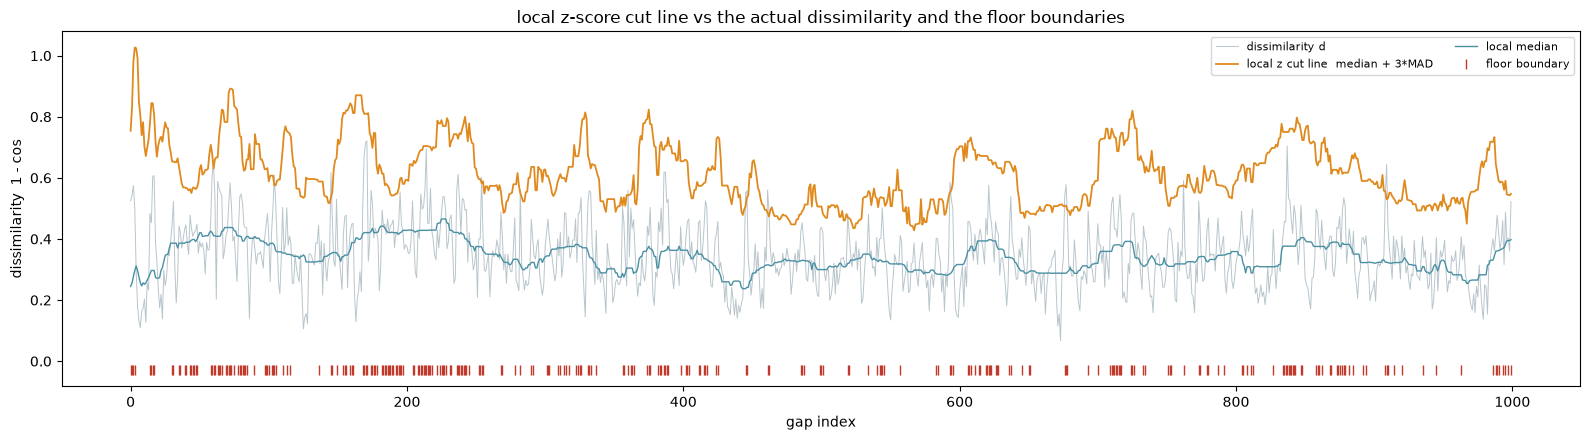

gaps whose d clears their own local cut line: 16


In [5]:
fig, ax = plt.subplots(figsize=(16, 4.5))

ax.plot(range(n), d, color='#b8c6cc', linewidth=0.7, label='dissimilarity d')
ax.plot(range(n), cut_line, color=C_ZONE, linewidth=1.3, label='local z cut line  median + 3*MAD')
ax.plot(range(n), loc_med, color=C_N, linewidth=1.0, label='local median')

bx = np.where(B)[0]

ax.plot(bx, np.full(len(bx), -0.03), '|', color=C_B, markersize=7, label='floor boundary')
ax.set_xlabel('gap index')
ax.set_ylabel('dissimilarity  1 - cos')
ax.set_title('local z-score cut line vs the actual dissimilarity and the floor boundaries')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

above = int((d > cut_line).sum())

print(f'gaps whose d clears their own local cut line: {above}')

## Diagnostic 2: MAD breakdown vs boundary density (the core test)

Left: local MAD against local boundary density `rho`, for every gap. Hypothesis 1 predicts MAD grows with density (the baseline swells as boundaries fill the window). Right: for each floor boundary, its local z-score against `rho`, with the `z = 3` decision line and the `rho = 0.5` breakdown line. Hypothesis 1 predicts boundaries in dense neighbourhoods score low z, so they fall under the line and the z-score misses them.

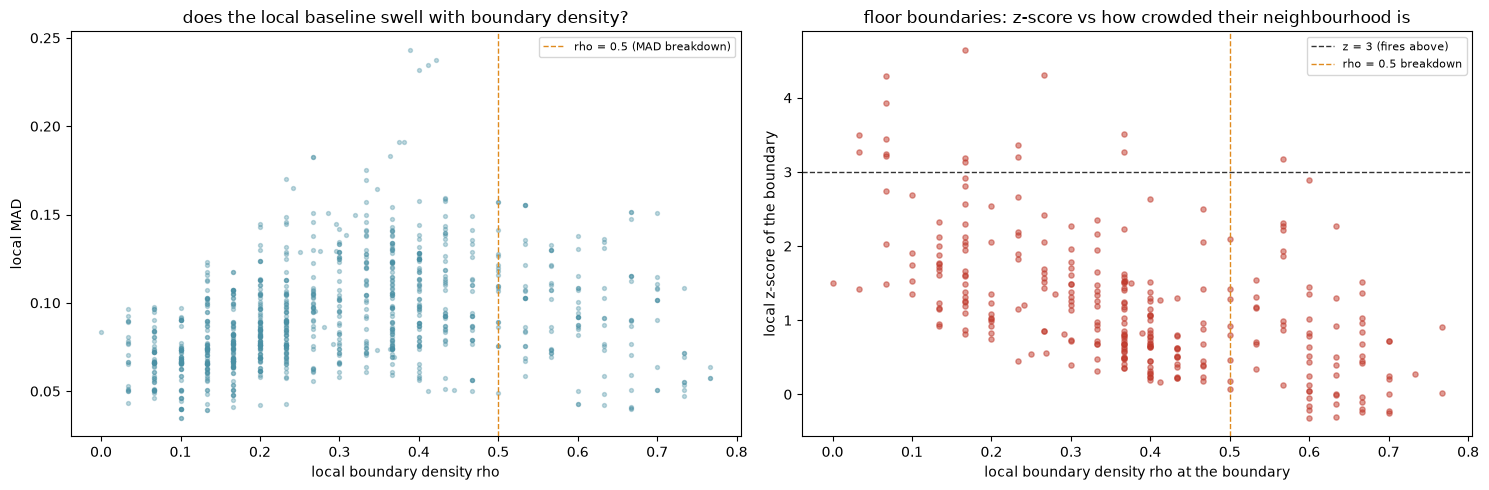

corr(local MAD, density)           : +0.32
corr(boundary z-score, density)    : -0.54
floor boundaries the z-score clears: 16 / 292  (5%)
median z of boundaries with rho<=0.5: 1.20
median z of boundaries with rho >0.5: 0.64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(rho, loc_mad, s=8, alpha=0.35, color=C_N)
axes[0].axvline(0.5, color=C_ZONE, linestyle='--', linewidth=1, label='rho = 0.5 (MAD breakdown)')
axes[0].set_xlabel('local boundary density rho')
axes[0].set_ylabel('local MAD')
axes[0].set_title('does the local baseline swell with boundary density?')
axes[0].legend(fontsize=8)

zb = z_loc[B]
rb = rho[B]
finite = np.isfinite(zb)

axes[1].scatter(rb[finite], zb[finite], s=14, alpha=0.5, color=C_B)
axes[1].axhline(THRESHOLD, color=C_LINE, linestyle='--', linewidth=1, label='z = 3 (fires above)')
axes[1].axvline(0.5, color=C_ZONE, linestyle='--', linewidth=1, label='rho = 0.5 breakdown')
axes[1].set_xlabel('local boundary density rho at the boundary')
axes[1].set_ylabel('local z-score of the boundary')
axes[1].set_title('floor boundaries: z-score vs how crowded their neighbourhood is')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

corr_mad = float(np.corrcoef(rho, loc_mad)[0, 1])
corr_bz = float(np.corrcoef(rb[finite], zb[finite])[0, 1])
seen = int(np.nansum(zb >= THRESHOLD))

print(f'corr(local MAD, density)           : {corr_mad:+.2f}')
print(f'corr(boundary z-score, density)    : {corr_bz:+.2f}')
print(f'floor boundaries the z-score clears: {seen} / {int(B.sum())}  ({seen / int(B.sum()):.0%})')
print(f'median z of boundaries with rho<=0.5: {np.nanmedian(zb[rb <= 0.5]):.2f}')
print(f'median z of boundaries with rho >0.5: {np.nanmedian(zb[rb > 0.5]):.2f}')

## Diagnostic 3: how much of the document is in the breakdown zone

Distribution of local boundary density across all gaps and across the boundaries themselves. The share of boundaries whose neighbourhood is more than half boundaries is the share the MAD breakdown directly explains.

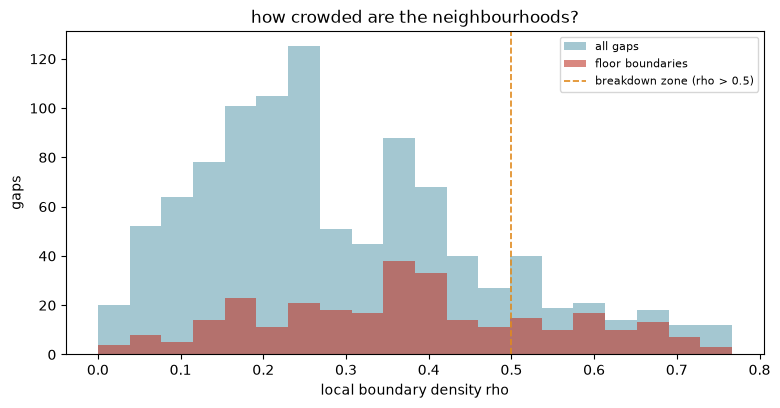

boundaries in the breakdown zone (rho>0.5): 67 / 292  (23%)
median neighbourhood density at a boundary : 0.37


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))

ax.hist(rho, bins=20, alpha=0.5, color=C_N, label='all gaps')
ax.hist(rho[B], bins=20, alpha=0.6, color=C_B, label='floor boundaries')
ax.axvline(0.5, color=C_ZONE, linestyle='--', linewidth=1.2, label='breakdown zone (rho > 0.5)')
ax.set_xlabel('local boundary density rho')
ax.set_ylabel('gaps')
ax.set_title('how crowded are the neighbourhoods?')
ax.legend(fontsize=8)
plt.show()

n_break = int((rho[B] > 0.5).sum())

print(f'boundaries in the breakdown zone (rho>0.5): {n_break} / {int(B.sum())}  '
      f'({n_break / int(B.sum()):.0%})')
print(f'median neighbourhood density at a boundary : {np.median(rho[B]):.2f}')

## Diagnostic 4: is it the window, or the level? (the A-vs-B decision)

If the bug is only the contaminated *local* window, a **global** robust baseline should recover the boundaries. So we compare the local z-score against a global z-score (median and MAD over the whole `d`). But note first: a global z-score is a monotonic transform of `d`, so thresholding it is arithmetically the same family as the floor. We check that equivalence directly (top-`k` gaps by global z vs the floor set), and then how many boundaries each baseline recovers at `z = 3`.

In [8]:
order = np.argsort(-z_glob)
k = int(B.sum())
top_global = set(int(i) for i in order[:k])
floor_set = set(int(i) for i in np.where(B)[0])
inter = len(top_global & floor_set)
union = len(top_global | floor_set)
recov_local = int(np.nansum(z_loc[B] >= THRESHOLD))
recov_global = int((z_glob[B] >= THRESHOLD).sum())
fp_local = int(np.nansum(z_loc[~B] >= THRESHOLD))
fp_global = int((z_glob[~B] >= THRESHOLD).sum())

print(f'top-{k} gaps by GLOBAL z vs the floor set: Jaccard {inter / union:.2f}  '
      f'({inter} shared of {union})')
print()
print(f'{"baseline":10s} {"boundaries recovered at z>=3":30s} {"non-boundaries flagged":s}')
print(f'{"local":10s} {recov_local:>4d} / {k:<25d} {fp_local}')
print(f'{"global":10s} {recov_global:>4d} / {k:<25d} {fp_global}')

top-292 gaps by GLOBAL z vs the floor set: Jaccard 1.00  (292 shared of 292)

baseline   boundaries recovered at z>=3   non-boundaries flagged
local        16 / 292                       0
global        5 / 292                       0


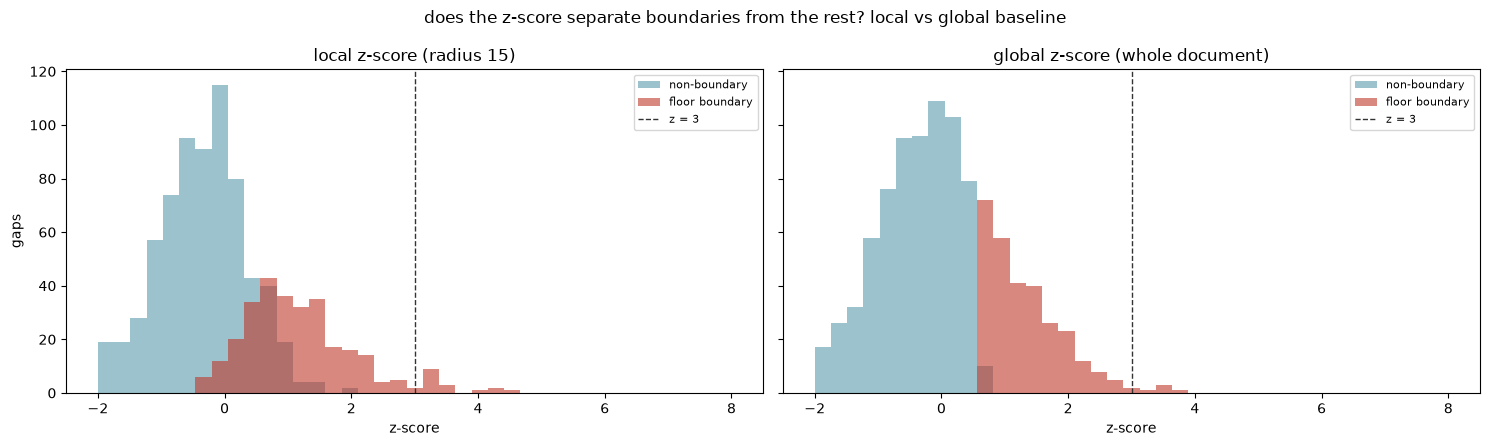

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
bins = np.linspace(-2, 8, 40)

for ax, z, title in [(axes[0], z_loc, 'local z-score (radius 15)'),
                     (axes[1], z_glob, 'global z-score (whole document)')]:
    ax.hist(z[~B][np.isfinite(z[~B])], bins=bins, alpha=0.55, color=C_N, label='non-boundary')
    ax.hist(z[B][np.isfinite(z[B])], bins=bins, alpha=0.6, color=C_B, label='floor boundary')
    ax.axvline(THRESHOLD, color=C_LINE, linestyle='--', linewidth=1, label='z = 3')
    ax.set_xlabel('z-score')
    ax.set_title(title)
    ax.legend(fontsize=8)

axes[0].set_ylabel('gaps')
fig.suptitle('does the z-score separate boundaries from the rest? local vs global baseline')
plt.tight_layout()
plt.show()

## Diagnostic 5 (bridge): is there shape information beyond level?

A global level threshold recovers the boundaries but is just the floor renamed: one global cut, no locality. The only route to a *locally adaptive* detector that does not break on density is a shape feature. As a first look, treat `d` as a signal and take peak prominence (`scipy.signal.find_peaks`), the modern cousin of Hearst's depth score. Prominence is a height *difference*, so it is invariant to shifting or scaling `d`, which is what an embedder swap does. Here we only check, on this one embedder, how many floor boundaries are prominent peaks and whether prominence rank matches level rank. The real payoff, cross-embedder stability, is what the next notebook must test.

floor boundaries that are strict local peaks: 137 / 292  (47%)
corr(level d, prominence) at boundary peaks : +0.77


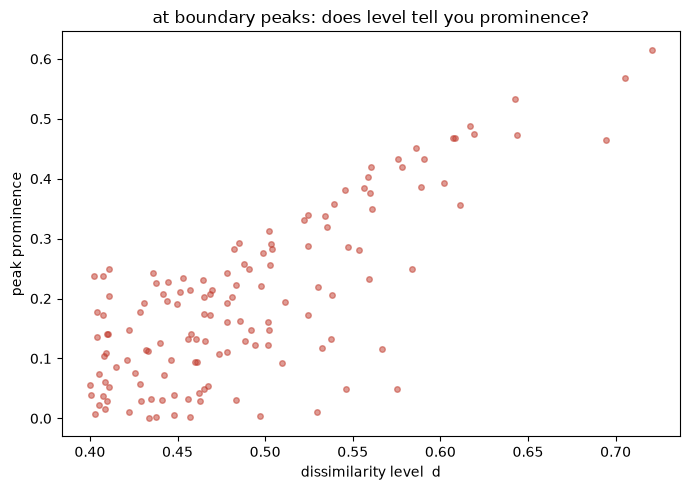

In [10]:
peaks, props = find_peaks(d, prominence=0)
prom = np.zeros(n)
prom[peaks] = props['prominences']

b_idx = np.where(B)[0]
is_peak = np.isin(b_idx, peaks)

print(f'floor boundaries that are strict local peaks: {int(is_peak.sum())} / {len(b_idx)}  '
      f'({is_peak.mean():.0%})')

pk_b = b_idx[is_peak]
rank_corr = float(np.corrcoef(d[pk_b], prom[pk_b])[0, 1])

print(f'corr(level d, prominence) at boundary peaks : {rank_corr:+.2f}')

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(d[pk_b], prom[pk_b], s=16, alpha=0.5, color=C_B)
ax.set_xlabel('dissimilarity level  d')
ax.set_ylabel('peak prominence')
ax.set_title('at boundary peaks: does level tell you prominence?')
plt.tight_layout()
plt.show()

## Observations

**Verdict. The z-score fails for two reasons, and the one I guessed first (MAD breakdown) is the smaller one. The bigger reason is that `threshold = 3.0` is an anomaly-scale bar, wrong for a document that is 29% boundaries. Neither reason is fixed by going global, because a global baseline is arithmetically just the floor.**

**The failure is confirmed and quantified.** The local z-score clears only **16 of 292** floor boundaries (5%), matching notebook 3. Exactly 16 gaps clear their own local `median + 3*MAD` line.

**MAD breakdown is real but partial (hypothesis 1, minority cause).** `corr(local MAD, density) = +0.32`: the local baseline does swell as the neighbourhood fills with boundaries, but weakly. `corr(boundary z, density) = -0.54`: a boundary in a crowded neighbourhood scores a lower z, and the median boundary z drops from **1.20** in sparse neighbourhoods to **0.64** in the breakdown zone. But only **67 of 292 (23%)** of boundaries actually sit in a majority-boundary window. So contamination explains at most a quarter of the misses.

**The dominant cause is a miscalibrated threshold (hypothesis 2, level not shape).** Even in *uncontaminated* neighbourhoods (`rho <= 0.5`) the median boundary reaches only **1.20** local sigma, nowhere near 3.0. The local contrast between a boundary and its surroundings is intrinsically modest on this signal, because boundaries here are defined by *absolute* dissimilarity (`d >= 0.4`) and are scattered across regions with different local baselines, so each boundary's excess over its own local baseline is small. A `3.0` bar is calibrated for rare anomalies; this document is not rare anomalies, it is 29% boundaries.

**Floor and z-score were never the same idea at different robustness.** With `global median d = 0.339` and `global MAD = 0.104`, the floor (`d >= 0.4`) sits at a global z of only **0.59**. So the floor implicitly cuts at ~0.6 sigma (lenient, 29% of gaps) while the z-score demands 3.0 sigma (strict, ~2% of gaps). They target completely different cut rates. That, not robustness, is why they disagree.

**A global baseline is not an independent option: it is the floor renamed.** The top-292 gaps by global z-score are *exactly* the floor set (**Jaccard 1.00**). A global z-score is a monotonic transform of `d`, so thresholding it is thresholding `d`, i.e. a floor. It therefore inherits the floor's absolute-level, embedder-coupled character, and as a single document-wide cut it would misfire on a heteroscedastic document (calm regions over-cut, turbulent regions under-cut). Going global fixes nothing and throws away the one virtue of locality.

**A caveat that reframes the whole question.** Only **137 of 292 (47%)** floor boundaries are even strict local peaks of `d`; at those peaks level and prominence correlate `+0.77`. Meaning: the floor's 292 cuts are *not* all genuine local topic-shift peaks. More than half are shoulders or plateau gaps that merely exceed the absolute 0.4 line. So every score in this notebook is measured against a reference (the floor) that is itself the crude mechanism under suspicion. "The z-score recovers 5% of the floor" partly means the z-score refuses to cut where the floor cuts *spuriously*.

**So what.**
- Locality is the right goal, but the current local z-score is broken for two independent reasons (miscalibrated 3.0 threshold, plus partial baseline contamination), and neither is cured by a global baseline.
- The candidate that keeps locality while dodging both failure modes is a **local shape measure** (depth / peak prominence): it references the immediately flanking minima rather than a wide window's median, so it is local, `O(n)`, variance-adaptive (a turbulent region raises its own bar), and not poisoned by how many boundaries sit nearby. But prominence is no silver bullet on `d`-as-given either (47% peak coverage), which is a signal that some of the target boundaries are floor artefacts.
- The real blocker is now the reference set. We cannot rank detectors against the floor, because the floor is what we doubt. The next experiment needs **trusted boundaries**: hand-marked topic shifts on a sample of KPC, and the synthetic passage where the facet structure is known by construction. Only against those can we honestly compare local-shape vs floor vs a re-thresholded local z-score.